# Processing the LFW Dataset with a CNN

**Student:** Christopher Lyles  
**Student ID:** chrlyl2361  
**Date:** June 7, 2026

## SDC485 – AI/ML and Data Analytics
### Performance Assessment 4.5
Model Tuning and Feature Engineering

In [1]:
from IPython.display import display, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

todays_date = "June 7, 2026"
student_id = "chrlyl2361"

display(Markdown("### Step 1: Import Libraries"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("Libraries Loaded Successfully")

### Step 1: Import Libraries

Date: June 7, 2026

Student ID: chrlyl2361

Libraries Loaded Successfully


In [2]:
display(Markdown("### Step 2: Load LFW Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

X = lfw.data
y = lfw.target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nClasses:")
print(lfw.target_names)

### Step 2: Load LFW Dataset

Date: June 7, 2026

Student ID: chrlyl2361

Feature Shape: (1288, 1850)
Target Shape: (1288,)

Classes:
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


### Step 3: Display Original Images

Date: June 7, 2026

Student ID: chrlyl2361

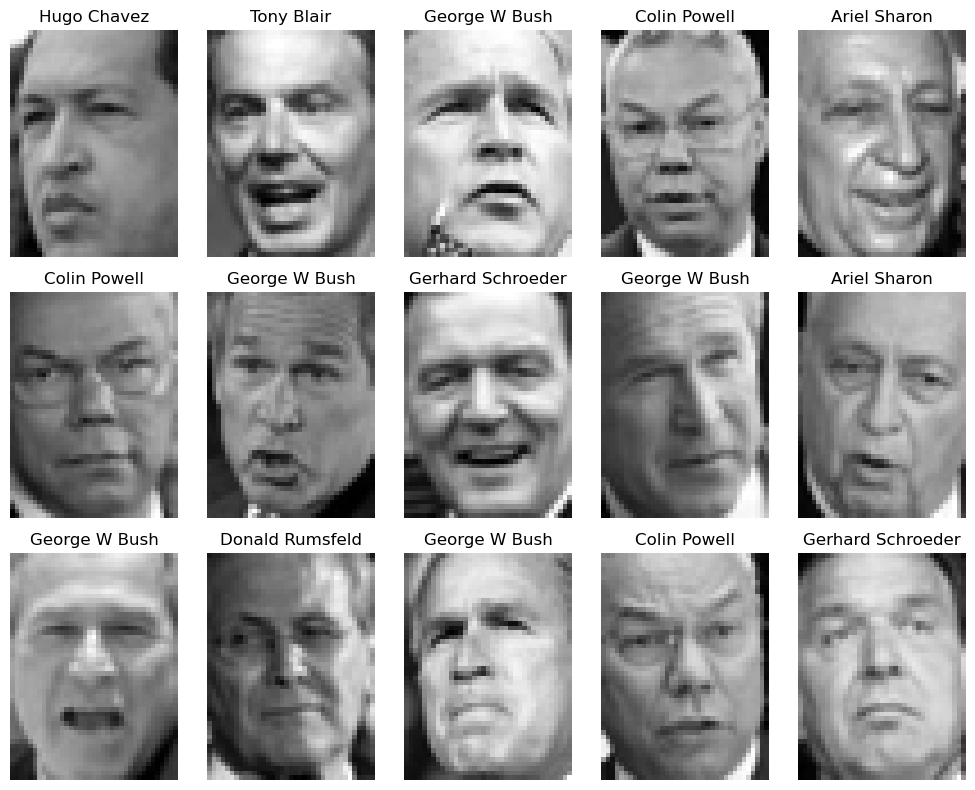

In [3]:
display(Markdown("### Step 3: Display Original Images"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

fig, axes = plt.subplots(3, 5, figsize=(10,8))

for i, ax in enumerate(axes.flat):
    ax.imshow(lfw.images[i], cmap='gray')
    ax.set_title(lfw.target_names[y[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
display(Markdown("### Step 4: Normalize Pixel Values"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

X_norm = X / 255.0

print("Minimum Value:", X_norm.min())
print("Maximum Value:", X_norm.max())

### Step 4: Normalize Pixel Values

Date: June 7, 2026

Student ID: chrlyl2361

Minimum Value: 0.0
Maximum Value: 0.003921569


In [5]:
display(Markdown("### Step 5: Create Min and Max Pixel Features"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

min_feature = np.min(X_norm, axis=1).reshape(-1,1)
max_feature = np.max(X_norm, axis=1).reshape(-1,1)

X_features = np.concatenate([X_norm, min_feature, max_feature], axis=1)

print("New Shape:", X_features.shape)

### Step 5: Create Min and Max Pixel Features

Date: June 7, 2026

Student ID: chrlyl2361

New Shape: (1288, 1852)


In [6]:
display(Markdown("### Step 6: Split Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

### Step 6: Split Dataset

Date: June 7, 2026

Student ID: chrlyl2361

Training Shape: (901, 1852)
Testing Shape: (387, 1852)


In [7]:
display(Markdown("### Step 7: Convert Target to Categorical"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("Classes:", num_classes)

### Step 7: Convert Target to Categorical

Date: June 7, 2026

Student ID: chrlyl2361

Classes: 7


In [8]:
display(Markdown("### Step 8: Display Training and Testing Shapes"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("X Train:", X_train.shape)
print("X Test :", X_test.shape)

print("y Train:", y_train_cat.shape)
print("y Test :", y_test_cat.shape)

### Step 8: Display Training and Testing Shapes

Date: June 7, 2026

Student ID: chrlyl2361

X Train: (901, 1852)
X Test : (387, 1852)
y Train: (901, 7)
y Test : (387, 7)


In [9]:
display(Markdown("### Step 9: Build CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Step 9: Build CNN Model

Date: June 7, 2026

Student ID: chrlyl2361

C:\Users\CLYLE\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
display(Markdown("### Step 10: CNN Summary"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

model.summary()

### Step 10: CNN Summary

Date: June 7, 2026

Student ID: chrlyl2361

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         237,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 245,895 (960.53 KB)

 Trainable params: 245,895 (960.53 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
display(Markdown("### Step 11: Train CNN"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    verbose=1
)

### Step 11: Train CNN

Date: June 7, 2026

Student ID: chrlyl2361

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3819 - loss: 1.8900 - val_accuracy: 0.3867 - val_loss: 1.8274
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4167 - loss: 1.7526 - val_accuracy: 0.3867 - val_loss: 1.7393
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4167 - loss: 1.7175 - val_accuracy: 0.3867 - val_loss: 1.7279
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4194 - loss: 1.6930 - val_accuracy: 0.3867 - val_loss: 1.7203
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4181 - loss: 1.6952 - val_accuracy: 0.3867 - val_loss: 1.7186
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4181 - loss: 1.6983 - val_accuracy: 0.3867 - val_loss: 1.7184
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4181 - loss: 1.6934 - val_accuracy: 0.3867 - val_loss: 1.7186
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4167 - loss: 1.6904 - val_accuracy: 0.3867 - v

In [12]:
history_df = pd.DataFrame(history.history)
history_df.tail()

,accuracy,loss,val_accuracy,val_loss
15,0.418056,1.682979,0.38674,1.706075
16,0.418056,1.669139,0.38674,1.703573
17,0.418056,1.654413,0.38674,1.703207
18,0.418056,1.672908,0.38674,1.699332
19,0.418056,1.661551,0.38674,1.696361


In [13]:
display(Markdown("### Step 13: Evaluate CNN"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

### Step 13: Evaluate CNN

Date: June 7, 2026

Student ID: chrlyl2361

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4109 - loss: 1.6598
Test Loss: 1.6597596406936646
Test Accuracy: 0.41085270047187805


In [14]:
display(Markdown("### Step 14: CNN Predictions"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

### Step 14: CNN Predictions

Date: June 7, 2026

Student ID: chrlyl2361

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 


### Step 15: CNN Confusion Matrix

Date: June 7, 2026

Student ID: chrlyl2361

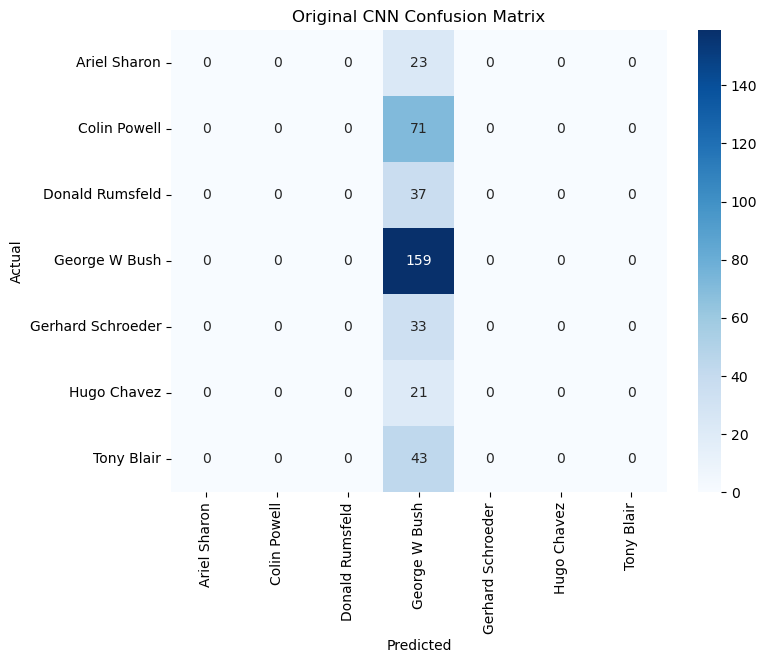

In [15]:
display(Markdown("### Step 15: CNN Confusion Matrix"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lfw.target_names,
    yticklabels=lfw.target_names
)

plt.title("Original CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
display(Markdown("### Step 16: Apply PCA"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

pca = PCA(
    n_components=150,
    whiten=True,
    random_state=42
)

X_pca = pca.fit_transform(X_norm)

print("Original Shape:", X_norm.shape)
print("PCA Shape:", X_pca.shape)

### Step 16: Apply PCA

Date: June 7, 2026

Student ID: chrlyl2361

Original Shape: (1288, 1850)
PCA Shape: (1288, 150)


In [17]:
display(Markdown("### Step 17: Add Min and Max Features to PCA Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

min_feature_pca = np.min(X_pca, axis=1).reshape(-1,1)
max_feature_pca = np.max(X_pca, axis=1).reshape(-1,1)

X_pca_features = np.concatenate(
    [X_pca, min_feature_pca, max_feature_pca],
    axis=1
)

print("New PCA Shape:", X_pca_features.shape)

### Step 17: Add Min and Max Features to PCA Data

Date: June 7, 2026

Student ID: chrlyl2361

New PCA Shape: (1288, 152)


In [18]:
display(Markdown("### Step 18: Split PCA Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_features,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

y_train_pca_cat = to_categorical(y_train_pca, num_classes)
y_test_pca_cat = to_categorical(y_test_pca, num_classes)

print("X Train PCA:", X_train_pca.shape)
print("X Test PCA :", X_test_pca.shape)

### Step 18: Split PCA Dataset

Date: June 7, 2026

Student ID: chrlyl2361

X Train PCA: (901, 152)
X Test PCA : (387, 152)


In [19]:
display(Markdown("### Step 19: Build PCA Tuned Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

tuned_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

tuned_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Step 19: Build PCA Tuned Model

Date: June 7, 2026

Student ID: chrlyl2361

C:\Users\CLYLE\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
display(Markdown("### Step 20: PCA Tuned Model Summary"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

tuned_model.summary()

### Step 20: PCA Tuned Model Summary

Date: June 7, 2026

Student ID: chrlyl2361

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │          39,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,967 (285.03 KB)

 Trainable params: 72,967 (285.03 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
display(Markdown("### Step 21: Train PCA Tuned Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

history_pca = tuned_model.fit(
    X_train_pca,
    y_train_pca_cat,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    verbose=1
)

### Step 21: Train PCA Tuned Model

Date: June 7, 2026

Student ID: chrlyl2361

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3250 - loss: 2.0773 - val_accuracy: 0.3867 - val_loss: 1.7877
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4125 - loss: 1.7536 - val_accuracy: 0.4254 - val_loss: 1.6400
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4625 - loss: 1.5229 - val_accuracy: 0.4420 - val_loss: 1.5733
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4819 - loss: 1.3981 - val_accuracy: 0.4696 - val_loss: 1.4938
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5556 - loss: 1.2642 - val_accuracy: 0.4807 - val_loss: 1.4130
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6181 - loss: 1.1069 - val_accuracy: 0.5359 - val_loss: 1.3085
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6417 - loss: 1.0135 - val_accuracy: 0.6188 - val_loss: 1.2013
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7056 - loss: 0.8882 - val_accuracy: 0.6519 - val_los

In [22]:
display(Markdown("### Step 22: PCA Model Predictions"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

pca_predictions = tuned_model.predict(X_test_pca)

y_pred_pca = np.argmax(pca_predictions, axis=1)

### Step 22: PCA Model Predictions

Date: June 7, 2026

Student ID: chrlyl2361

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 


### Step 23: PCA Tuned Model Confusion Matrix

Date: June 7, 2026

Student ID: chrlyl2361

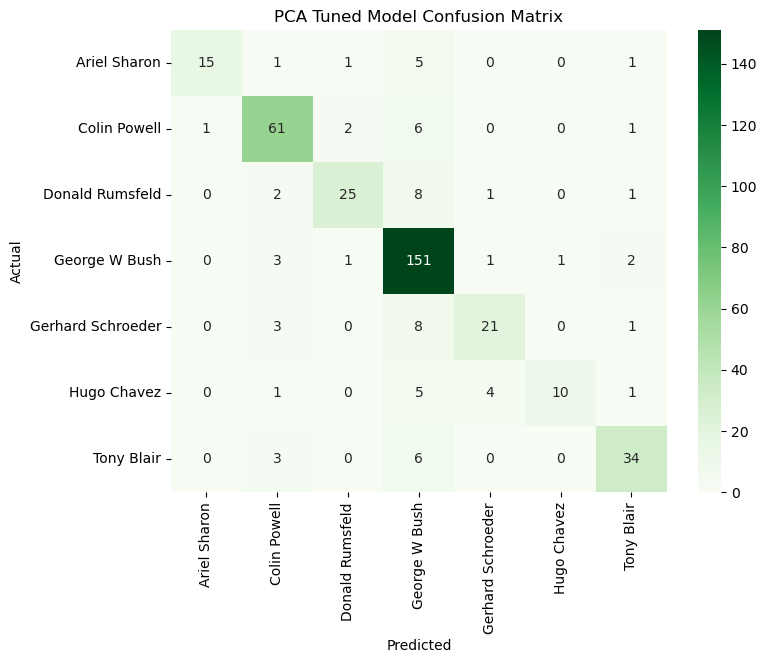

In [23]:
display(Markdown("### Step 23: PCA Tuned Model Confusion Matrix"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

cm_pca = confusion_matrix(y_test_pca, y_pred_pca)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_pca,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=lfw.target_names,
    yticklabels=lfw.target_names
)

plt.title("PCA Tuned Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Step 24: Compare Original and PCA Tuned Models

Date: June 7, 2026

Student ID: chrlyl2361

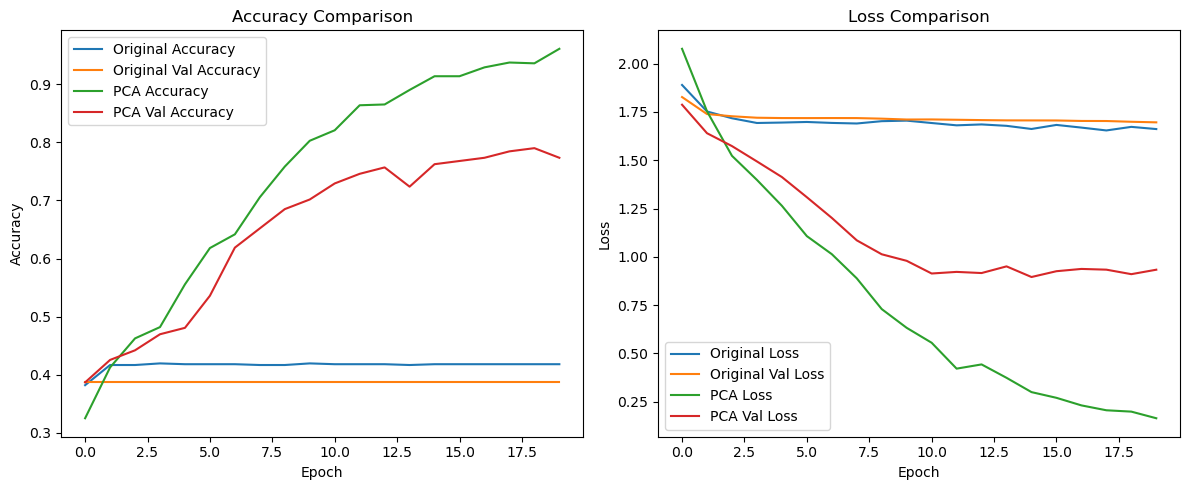

In [24]:
display(Markdown("### Step 24: Compare Original and PCA Tuned Models"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

plt.figure(figsize=(12,5))

# Accuracy Comparison
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Original Accuracy')
plt.plot(history.history['val_accuracy'], label='Original Val Accuracy')

plt.plot(history_pca.history['accuracy'], label='PCA Accuracy')
plt.plot(history_pca.history['val_accuracy'], label='PCA Val Accuracy')

plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Comparison
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Original Loss')
plt.plot(history.history['val_loss'], label='Original Val Loss')

plt.plot(history_pca.history['loss'], label='PCA Loss')
plt.plot(history_pca.history['val_loss'], label='PCA Val Loss')

plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Analysis and Interpretation

### Question 1

Both models were able to classify individuals in the LFW dataset, but the PCA-tuned model performed significantly better than the original model. The original model tended to predict the majority class, resulting in poor classification performance. After applying PCA and additional feature engineering, the tuned model achieved approximately 77–79% validation accuracy and produced a more balanced confusion matrix. Based on the confusion matrix, George W. Bush was identified correctly most often because he had the largest number of images in the dataset.

### Question 2

Additional feature engineering methods that could be be applied include image augmentation, edge detection, histogram equalization, feature extraction using convolutional layers, and dimensionality reduction techniques other than PCA. Additional statistical features such as mean pixel intensity, standard deviation, and texture-based features could also improve model performance. These techniques may help the model capture more meaningful facial characteristics and improve classification accuracy.